这个 notebook 是 task1.3 完整版。它实现二维无人机环境、三个 tabular RL agents、repeated experiments、统计检验、可视化，并生成 `AIUSAGE.md` 初稿。

正式实验要求：`FAST_DEBUG=False`，每个 agent 每个 run 训练 15000 episodes，测试 300 episodes，多次 run 后取 mean ± std。

In [ ]:

#1. 安装依赖库
# Colab 通常已经安装这些库；这里补装是为了保证环境一致。
!pip -q install numpy matplotlib scipy pandas tqdm

In [ ]:
# 2. 导入库
import os
import json
import math
import random
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from scipy.stats import ttest_ind
from matplotlib.patches import Rectangle, Circle

# 所有输出文件都会保存在这里
OUTPUT_DIR = Path("/content/task1_3_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("输出文件夹:", OUTPUT_DIR)

输出文件夹: /content/task1_3_outputs


In [ ]:
#3. 全局参数配置：正式实验前主要检查这一格
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# True  = 快速检查代码，不用于报告
# False = 正式实验，符合指导书：15000 train episodes + 300 test episodes
FAST_DEBUG = False

# 老师纸上写的“1实验15000，2实验15000，...，取平均”就是 N_RUNS
OFFICIAL_N_RUNS = 5
DEBUG_N_RUNS = 1

# 当多个动作 Q 值完全相等时，是否用“更靠近目标且不碰撞”的规则打破平局。
# 三个 agent 必须保持同样设置。若老师要求最纯粹的 Q-learning，可改成 False。
USE_SAFE_DISTANCE_TIE_BREAK = True

COMMON_CFG = {
    "num_train_episodes": 15000,     # 每个 agent 每个 run 的训练 episode 数
    "num_test_episodes": 300,        # 每个 agent 每个 run 的测试 episode 数
    "gamma": 0.99,                   # 折扣因子：越接近 1 越重视未来奖励
    "alpha": 0.10,                   # 学习率：越大更新越快，但可能不稳定
    "epsilon_start": 1.0,            # 初始探索率
    "epsilon_min": 0.01,             # 最小探索率
    "epsilon_decay": 0.997,          # 探索率衰减系数
    "test_epsilon": 0.005,           # 测试时探索率
    "prospect_alpha": 0.88,          # Prospect Theory 参数，指导书指定
    "prospect_beta": 0.88,           # Prospect Theory 参数，指导书指定
    "prospect_lambda": 2.35,         # 损失厌恶系数，指导书指定
    "risk_eta": 0.5,                 # 风险敏感参数，可从 {0.5,1.0,2.0} 选，0.5较稳定
    "optimistic_q0": 5.0,            # 乐观初始化，帮助早期探索
    "use_safe_distance_tie_break": USE_SAFE_DISTANCE_TIE_BREAK,
}

# Variant 1 / Scheme 1 参数
ENV_CFG = {
    "name": "Variant 1 / Scheme 1",
    "x_range": (0.0, 24.0),
    "y_range": (0.0, 12.0),
    "station_center": (21.5, 8.5),
    "station_radius": 0.9,
    "charge_power": 0.025,
    "start_mean": (3.5, 6.0),
    "start_sigma": 1.8,
    "start_clip_x": (1.0, 7.0),
    "start_clip_y": (2.0, 10.0),
    "wind_x_range": (-0.11, 0.11),
    "wind_y_range": (-0.11, 0.11),
    "wind_update_period": 15,
    "obstacles": [
        (10.0, 2.0, 11.5, 5.5),
        (13.0, 7.0, 14.5, 10.0),
        (16.5, 3.5, 18.0, 6.5),
        (19.0, 9.0, 20.5, 11.5),
    ],
    "speed_values": [0.10, 0.25, 0.40, 0.60],
    "action_target_speeds": [0.10, 0.25, 0.40, 0.60],
    "state_bins": (14, 14, 12, 4),  # 14*14*12*4 = 9408 states
    "success_battery_threshold": 0.90,
    "failure_battery_threshold": 0.04,
    "success_deadline": 140,
    "fail_step_limit": 200,
    "success_reward": 90.0,
    "discharge_penalty": -170.0,
    "step_base_reward": -1.0,
    "step_speed_penalty_coef": 0.030,
    "step_station_bonus_coef": 0.12,
    "battery_v2_coef": 0.018,
    "battery_w_norm2_coef": 0.003,
    "battery_abs_v_coef": 0.002,
}

if FAST_DEBUG:
    N_RUNS = DEBUG_N_RUNS
    RUN_SEEDS = [100]
    EXP_CFG = COMMON_CFG.copy()
    EXP_CFG["num_train_episodes"] = 500
    EXP_CFG["num_test_episodes"] = 50
else:
    N_RUNS = OFFICIAL_N_RUNS
    RUN_SEEDS = [100, 200, 300, 400, 500][:N_RUNS]
    EXP_CFG = COMMON_CFG.copy()

CHECKPOINT_PATH = OUTPUT_DIR / "task1_3_repeated_runs.pkl"

print("当前方案:", ENV_CFG["name"])
print("FAST_DEBUG =", FAST_DEBUG)
print("N_RUNS =", N_RUNS)
print("RUN_SEEDS =", RUN_SEEDS)
print("Train episodes per agent per run =", EXP_CFG["num_train_episodes"])
print("Test episodes per agent per run  =", EXP_CFG["num_test_episodes"])
print("Tie-break heuristic =", EXP_CFG["use_safe_distance_tie_break"])

当前方案: Variant 1 / Scheme 1
FAST_DEBUG = False
N_RUNS = 5
RUN_SEEDS = [100, 200, 300, 400, 500]
Train episodes per agent per run = 15000
Test episodes per agent per run  = 300
Tie-break heuristic = True


In [ ]:
#4. 工具函数：边界、碰撞检测、离散化、滑动平均
# 老师问的“Столкновение с препятствиями”主要看这里和 DroneEnv._apply_dynamics。

def clip(v, low, high):
    # 把数值限制在 [low, high] 内，防止飞出边界
    return max(low, min(high, v))


def point_in_rect(x, y, rect):
    # 判断点是否在矩形障碍物内部
    x1, y1, x2, y2 = rect
    return (x1 <= x <= x2) and (y1 <= y <= y2)


def orientation(ax, ay, bx, by, cx, cy):
    # 判断三点方向：0 共线，1 顺时针，2 逆时针
    val = (by - ay) * (cx - bx) - (bx - ax) * (cy - by)
    if abs(val) < 1e-12:
        return 0
    return 1 if val > 0 else 2


def on_segment(ax, ay, bx, by, cx, cy):
    # 共线时判断 B 是否在线段 AC 上
    eps = 1e-12
    return min(ax, cx)-eps <= bx <= max(ax, cx)+eps and min(ay, cy)-eps <= by <= max(ay, cy)+eps


def segments_intersect(x1, y1, x2, y2, x3, y3, x4, y4):
    # 判断两条线段是否相交
    o1 = orientation(x1, y1, x2, y2, x3, y3)
    o2 = orientation(x1, y1, x2, y2, x4, y4)
    o3 = orientation(x3, y3, x4, y4, x1, y1)
    o4 = orientation(x3, y3, x4, y4, x2, y2)
    if o1 != o2 and o3 != o4:
        return True
    if o1 == 0 and on_segment(x1, y1, x3, y3, x2, y2): return True
    if o2 == 0 and on_segment(x1, y1, x4, y4, x2, y2): return True
    if o3 == 0 and on_segment(x3, y3, x1, y1, x4, y4): return True
    if o4 == 0 and on_segment(x3, y3, x2, y2, x4, y4): return True
    return False


def segment_hits_rect(x1, y1, x2, y2, rect):
    # 判断无人机一步移动线段是否与一个矩形障碍物相交
    rx1, ry1, rx2, ry2 = rect
    if point_in_rect(x1, y1, rect) or point_in_rect(x2, y2, rect):
        return True
    edges = [(rx1, ry1, rx2, ry1), (rx2, ry1, rx2, ry2), (rx2, ry2, rx1, ry2), (rx1, ry2, rx1, ry1)]
    for ex1, ey1, ex2, ey2 in edges:
        if segments_intersect(x1, y1, x2, y2, ex1, ey1, ex2, ey2):
            return True
    return False


def segment_hits_any_obstacle(x1, y1, x2, y2, obstacles):
    # 判断一步移动是否碰到任意障碍物
    return any(segment_hits_rect(x1, y1, x2, y2, rect) for rect in obstacles)


def make_uniform_bin_index(value, low, high, n_bins):
    # 把连续数值映射到离散编号 0..n_bins-1
    value = np.clip(value, low, high)
    edges = np.linspace(low, high, n_bins + 1)
    idx = np.digitize(value, edges[1:-1], right=False)
    return int(np.clip(idx, 0, n_bins - 1))


def nearest_speed_index(v, speed_values):
    # 将当前速度映射到最近的速度档位
    arr = np.array(speed_values)
    return int(np.argmin(np.abs(arr - v)))


def moving_average(x, window=150):
    # 计算滑动平均，用于 learning curve
    x = np.asarray(x, dtype=np.float64)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")

In [ ]:
# 5. DroneEnv 环境类
# 环境实现：状态、动作、风、障碍物、电池、奖励、终止条件。

class DroneEnv:
    def __init__(self, cfg, seed=42):
        self.cfg = cfg
        self.rng = np.random.default_rng(seed)
        self.xmin, self.xmax = cfg["x_range"]
        self.ymin, self.ymax = cfg["y_range"]
        self.station_x, self.station_y = cfg["station_center"]
        self.station_radius = cfg["station_radius"]
        self.charge_power = cfg["charge_power"]
        self.speed_values = cfg["speed_values"]
        self.action_target_speeds = cfg["action_target_speeds"]
        self.directions = [0.0, np.pi/2, np.pi, 3*np.pi/2]  # 右、上、左、下
        self.actions = [(theta, v) for theta in self.directions for v in self.action_target_speeds]
        self.n_actions = len(self.actions)
        self.n_dx, self.n_dy, self.n_b, self.n_v = cfg["state_bins"]
        self.n_states = self.n_dx * self.n_dy * self.n_b * self.n_v
        self.reset()

    def sample_start_position(self):
        # 初始位置：正态分布采样，然后 clip 到指定范围
        mx, my = self.cfg["start_mean"]
        sigma = self.cfg["start_sigma"]
        x = np.clip(self.rng.normal(mx, sigma), *self.cfg["start_clip_x"])
        y = np.clip(self.rng.normal(my, sigma), *self.cfg["start_clip_y"])
        return float(x), float(y)

    def sample_wind(self):
        # Variant 1：wx, wy 都服从 U(-0.11, 0.11)
        wx = self.rng.uniform(*self.cfg["wind_x_range"])
        wy = self.rng.uniform(*self.cfg["wind_y_range"])
        return float(wx), float(wy)

    def is_in_station(self, x, y):
        # 判断是否进入充电站圆形区域
        return np.hypot(x - self.station_x, y - self.station_y) < self.station_radius

    def get_state_index(self):
        # 状态 st=(delta_x, delta_y, battery, speed)，然后离散化为 Q-table 索引
        dx = self.station_x - self.x
        dy = self.station_y - self.y
        dx_idx = make_uniform_bin_index(dx, -self.xmax, self.xmax, self.n_dx)
        dy_idx = make_uniform_bin_index(dy, -self.ymax, self.ymax, self.n_dy)
        b_idx = make_uniform_bin_index(self.b, 0.0, 1.0, self.n_b)
        v_idx = nearest_speed_index(self.v, self.speed_values)
        return np.ravel_multi_index((dx_idx, dy_idx, b_idx, v_idx), (self.n_dx, self.n_dy, self.n_b, self.n_v))

    def reset(self):
        # 开始一个新 episode
        self.x, self.y = self.sample_start_position()
        self.b = 1.0  # 初始电量采用满电；三个 agent 一致
        self.v = self.speed_values[0]
        self.t = 0
        self.total_reward = 0.0
        self.total_energy_used = 0.0
        self.collision_count = 0
        self.wind = self.sample_wind()
        return self.get_state_index()

    def _refresh_wind_if_needed(self):
        # 每 15 步更新一次风，两次更新之间保持不变
        period = self.cfg["wind_update_period"]
        if self.t > 0 and (self.t % period == 0):
            self.wind = self.sample_wind()

    def _apply_dynamics(self, theta, target_v):
        # 动力学 + 碰撞模型
        # 碰撞采用“禁止进入”：若移动线段与障碍物相交，则坐标不更新，并记录 collision。
        wx, wy = self.wind
        self.v = target_v
        nx = self.x + self.v * np.cos(theta) + wx
        ny = self.y + self.v * np.sin(theta) + wy
        nx = clip(nx, self.xmin, self.xmax)
        ny = clip(ny, self.ymin, self.ymax)
        collision = segment_hits_any_obstacle(self.x, self.y, nx, ny, self.cfg["obstacles"])
        if collision:
            self.collision_count += 1
        else:
            self.x, self.y = nx, ny
        return collision

    def _battery_update(self, in_station):
        # 非线性电池消耗：速度平方 + 风平方 + 速度绝对值；在充电站内增加电量
        wx, wy = self.wind
        wind_norm2 = wx**2 + wy**2
        energy_use = (
            self.cfg["battery_v2_coef"] * self.v**2
            + self.cfg["battery_w_norm2_coef"] * wind_norm2
            + self.cfg["battery_abs_v_coef"] * abs(self.v)
        )
        charge_gain = self.charge_power if in_station else 0.0
        self.b = min(1.0, max(0.0, self.b - energy_use + charge_gain))
        self.total_energy_used += energy_use
        return energy_use, charge_gain

    def _is_success(self, in_station):
        # 成功条件：进入站点，电量高于阈值，且不超过 deadline
        return in_station and self.b > self.cfg["success_battery_threshold"] and self.t <= self.cfg["success_deadline"]

    def step(self, action_idx):
        # 执行一个动作，返回 next_state, reward, done, info
        self._refresh_wind_if_needed()
        theta, target_v = self.actions[action_idx]
        collision = self._apply_dynamics(theta, target_v)
        in_station = self.is_in_station(self.x, self.y)
        energy_use, charge_gain = self._battery_update(in_station)
        self.t += 1

        success = self._is_success(in_station)
        battery_fail = self.b < self.cfg["failure_battery_threshold"]
        time_fail = self.t >= self.cfg["fail_step_limit"]
        done = success or battery_fail or time_fail

        if success:
            reward = self.cfg["success_reward"]
        elif battery_fail:
            reward = self.cfg["discharge_penalty"]
        else:
            reward = self.cfg["step_base_reward"] - self.cfg["step_speed_penalty_coef"] * self.v**2 + self.cfg["step_station_bonus_coef"] * self.cfg["charge_power"] * float(in_station)

        self.total_reward += reward
        info = {
            "x": self.x, "y": self.y, "battery": self.b, "speed": self.v,
            "wind": self.wind, "collision": collision, "in_station": in_station,
            "energy_use": energy_use, "charge_gain": charge_gain,
            "success": success, "battery_fail": battery_fail, "time_fail": time_fail,
            "step": self.t,
        }
        return self.get_state_index(), reward, done, info

In [ ]:
#6. 环境 smoke test
# 应该看到：状态总数 9408，动作总数 16。

env = DroneEnv(ENV_CFG, seed=SEED)
state = env.reset()
print("初始状态索引:", state)
print("状态总数:", env.n_states)
print("动作总数:", env.n_actions)
print("初始位置:", (round(env.x, 3), round(env.y, 3)))
print("初始风:", env.wind)
print("初始电量:", env.b)

for i in range(5):
    a = np.random.randint(env.n_actions)
    next_state, reward, done, info = env.step(a)
    print(f"step={i+1}, action={a}, reward={reward:.3f}, battery={info['battery']:.3f}, collision={info['collision']}, x={info['x']:.2f}, y={info['y']:.2f}, done={done}")
    if done:
        break

初始状态索引: 8540
状态总数: 9408
动作总数: 16
初始位置: (1.0, 3.656)
初始风: (0.05745073443787764, 0.06293414716092983)
初始电量: 1.0
step=1, action=6, reward=-1.005, battery=0.996, collision=False, x=1.06, y=4.12, done=False
step=2, action=3, reward=-1.011, battery=0.989, collision=False, x=1.71, y=4.18, done=False
step=3, action=12, reward=-1.000, battery=0.988, collision=False, x=1.77, y=4.14, done=False
step=4, action=14, reward=-1.005, battery=0.984, collision=False, x=1.83, y=3.81, done=False
step=5, action=10, reward=-1.005, battery=0.981, collision=False, x=1.49, y=3.87, done=False


In [ ]:
#7. 三个 Tabular Agent
# Rational: 标准 Q-learning
# Prospect: 对 reward 做 Prospect Theory 变换后再 Q-learning
# Risk-sensitive: 使用 U=exp(-eta Q) 的风险敏感更新

def one_step_lookahead_score(env, action_idx):
    # tie-break 分数：更接近充电站、不碰撞、速度略低的动作分数更小
    theta, target_v = env.actions[action_idx]
    wx, wy = env.wind
    nx = clip(env.x + target_v * np.cos(theta) + wx, env.xmin, env.xmax)
    ny = clip(env.y + target_v * np.sin(theta) + wy, env.ymin, env.ymax)
    hit = segment_hits_any_obstacle(env.x, env.y, nx, ny, env.cfg["obstacles"])
    if hit:
        nx, ny = env.x, env.y
    return np.hypot(env.station_x - nx, env.station_y - ny) + (4.0 if hit else 0.0) + 0.05 * target_v


class BaseTabularAgent:
    def __init__(self, n_states, n_actions, alpha, gamma, name="Base"):
        self.n_states = n_states
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.name = name
        self.Q = np.zeros((n_states, n_actions), dtype=np.float64)

    def select_action(self, state, epsilon, rng, env=None, use_safe_distance_tie_break=False):
        # epsilon-greedy：以 epsilon 随机探索，否则选择 Q 最大动作
        if rng.random() < epsilon:
            return int(rng.integers(self.n_actions))
        q = self.Q[state]
        best_actions = np.flatnonzero(np.isclose(q, np.max(q)))
        if len(best_actions) == 1:
            return int(best_actions[0])
        if use_safe_distance_tie_break and env is not None:
            scored = [(one_step_lookahead_score(env, a), a) for a in best_actions]
            scored.sort(key=lambda x: x[0])
            return int(scored[0][1])
        return int(rng.choice(best_actions))

    def update(self, state, action, reward, next_state, done):
        raise NotImplementedError


class RationalQLearningAgent(BaseTabularAgent):
    def __init__(self, n_states, n_actions, alpha, gamma):
        super().__init__(n_states, n_actions, alpha, gamma, name="Rational Q-learning")

    def update(self, state, action, reward, next_state, done):
        target = reward if done else reward + self.gamma * np.max(self.Q[next_state])
        self.Q[state, action] += self.alpha * (target - self.Q[state, action])


class ProspectQLearningAgent(BaseTabularAgent):
    def __init__(self, n_states, n_actions, alpha, gamma, alpha_p=0.88, beta_p=0.88, lambda_p=2.35):
        super().__init__(n_states, n_actions, alpha, gamma, name="Prospect Q-learning")
        self.alpha_p = alpha_p
        self.beta_p = beta_p
        self.lambda_p = lambda_p

    def value_function(self, r):
        # Prospect Theory：正奖励压缩，负奖励被损失厌恶系数放大
        if r >= 0:
            return r ** self.alpha_p
        return -self.lambda_p * ((-r) ** self.beta_p)

    def update(self, state, action, reward, next_state, done):
        subjective_reward = self.value_function(reward)
        target = subjective_reward if done else subjective_reward + self.gamma * np.max(self.Q[next_state])
        self.Q[state, action] += self.alpha * (target - self.Q[state, action])


class RiskSensitiveQLearningAgent(BaseTabularAgent):
    def __init__(self, n_states, n_actions, alpha, gamma, eta=0.5):
        super().__init__(n_states, n_actions, alpha, gamma, name="Risk-sensitive Q-learning")
        self.eta = eta
        self.U = np.ones((n_states, n_actions), dtype=np.float64)  # Q=0 时 U=1

    def set_optimistic_q(self, q0):
        self.Q[:, :] = q0
        self.U[:, :] = np.exp(-self.eta * q0)

    def update(self, state, action, reward, next_state, done):
        # 用 log 形式避免 exp 溢出
        old_u = self.U[state, action]
        if done:
            log_target_u = -self.eta * reward
        else:
            min_next_u = max(np.min(self.U[next_state]), 1e-300)
            log_target_u = -self.eta * reward + self.gamma * np.log(min_next_u)
        target_u = np.exp(np.clip(log_target_u, -700, 700))
        new_u = np.clip((1.0 - self.alpha) * old_u + self.alpha * target_u, 1e-300, 1e300)
        self.U[state, action] = new_u
        self.Q[state, action] = -(1.0 / self.eta) * np.log(new_u)


def build_agent(agent_type, env, cfg):
    if agent_type == "rational":
        return RationalQLearningAgent(env.n_states, env.n_actions, cfg["alpha"], cfg["gamma"])
    if agent_type == "prospect":
        return ProspectQLearningAgent(env.n_states, env.n_actions, cfg["alpha"], cfg["gamma"], cfg["prospect_alpha"], cfg["prospect_beta"], cfg["prospect_lambda"])
    if agent_type == "risk":
        return RiskSensitiveQLearningAgent(env.n_states, env.n_actions, cfg["alpha"], cfg["gamma"], cfg["risk_eta"])
    raise ValueError(agent_type)


def optimistic_init(agent, q0=5.0):
    # 三个 agent 使用统一乐观初始化
    if isinstance(agent, RiskSensitiveQLearningAgent):
        agent.set_optimistic_q(q0)
    else:
        agent.Q[:, :] = q0

In [ ]:
#8. 训练和测试函数

def train_agent(agent, env_cfg, cfg, seed=42, log_every=1000, show_progress=True):
    rng = np.random.default_rng(seed + 999)
    env = DroneEnv(env_cfg, seed=seed)
    epsilon = cfg["epsilon_start"]
    history = {"episode_reward": [], "episode_length": [], "collisions": [], "final_battery": [], "epsilon": [], "success": []}
    iterator = tqdm(range(cfg["num_train_episodes"]), desc=f"Training {agent.name}") if show_progress else range(cfg["num_train_episodes"])

    for ep in iterator:
        state = env.reset()
        done = False
        last_info = None
        while not done:
            action = agent.select_action(state, epsilon, rng, env=env, use_safe_distance_tie_break=cfg["use_safe_distance_tie_break"])
            next_state, reward, done, info = env.step(action)
            agent.update(state, action, reward, next_state, done)
            state = next_state
            last_info = info

        history["episode_reward"].append(env.total_reward)
        history["episode_length"].append(env.t)
        history["collisions"].append(env.collision_count)
        history["final_battery"].append(env.b)
        history["epsilon"].append(epsilon)
        history["success"].append(bool(last_info["success"]))
        epsilon = max(cfg["epsilon_min"], epsilon * cfg["epsilon_decay"])

        if log_every is not None and (ep + 1) % log_every == 0:
            recent_success = np.mean(history["success"][-200:]) * 100
            recent_reward = np.mean(history["episode_reward"][-200:])
            print(f"{agent.name:28s} | ep={ep+1:5d} | eps={epsilon:.4f} | recent_reward={recent_reward:.2f} | recent_success={recent_success:.1f}%")
    return history


def summarize_results(results):
    success_arr = np.array(results["success"], dtype=bool)
    collision_episode_arr = np.array(results["collision_episode"], dtype=bool)
    success_steps = np.array(results["success_steps"], dtype=np.float64)
    mean_success_time = float(np.mean(success_steps)) if len(success_steps) > 0 else np.nan
    return {
        "success_rate_percent": float(np.mean(success_arr) * 100.0),
        "mean_episode_length": float(np.mean(results["episode_length"])),
        "mean_success_time": mean_success_time,
        "mean_energy_used": float(np.mean(results["energy_used"])),
        "collision_episode_percent": float(np.mean(collision_episode_arr) * 100.0),
        "mean_final_battery": float(np.mean(results["final_battery"])),
    }


def evaluate_agent(agent, env_cfg, cfg, seed_base=3000, record_trajectories=4, show_progress=True):
    results = {"success": [], "episode_length": [], "success_steps": [], "energy_used": [], "collisions": [], "collision_episode": [], "final_battery": [], "final_x": [], "final_y": [], "trajectories": []}
    iterator = tqdm(range(cfg["num_test_episodes"]), desc=f"Testing {agent.name}") if show_progress else range(cfg["num_test_episodes"])

    for ep in iterator:
        env = DroneEnv(env_cfg, seed=seed_base + ep)  # 三个 agent 测试时面对相同种子
        rng = np.random.default_rng(seed_base + 10000 + ep)
        state = env.reset()
        done = False
        traj = []
        last_info = None

        while not done:
            if ep < record_trajectories:
                traj.append((env.x, env.y, env.b))
            action = agent.select_action(state, cfg["test_epsilon"], rng, env=env, use_safe_distance_tie_break=cfg["use_safe_distance_tie_break"])
            next_state, reward, done, info = env.step(action)
            state = next_state
            last_info = info

        if ep < record_trajectories:
            traj.append((env.x, env.y, env.b))
            results["trajectories"].append({"trajectory": traj, "success": bool(last_info["success"]), "final_step": env.t, "collisions": env.collision_count})

        success = bool(last_info["success"])
        results["success"].append(success)
        results["episode_length"].append(env.t)
        if success:
            results["success_steps"].append(env.t)
        results["energy_used"].append(env.total_energy_used)
        results["collisions"].append(env.collision_count)
        results["collision_episode"].append(env.collision_count > 0)
        results["final_battery"].append(env.b)
        results["final_x"].append(env.x)
        results["final_y"].append(env.y)

    return results, summarize_results(results)

In [ ]:
#9. 表格、聚合和 t-test 函数

def print_summary_table(summary_dict, title="Summary"):
    print("\n" + title)
    print("=" * 125)
    print(f"{'Agent':<28} {'Success %':>12} {'MeanLen':>12} {'MeanSuccTime':>15} {'MeanEnergy':>14} {'Collision %':>14} {'MeanBattery':>14}")
    print("=" * 125)
    for name, s in summary_dict.items():
        mst = "nan" if np.isnan(s["mean_success_time"]) else f"{s['mean_success_time']:.2f}"
        print(f"{name:<28} {s['success_rate_percent']:12.2f} {s['mean_episode_length']:12.2f} {mst:>15} {s['mean_energy_used']:14.4f} {s['collision_episode_percent']:14.2f} {s['mean_final_battery']:14.4f}")
    print("=" * 125)


def aggregate_summaries(summary_list):
    metric_names = ["success_rate_percent", "mean_episode_length", "mean_success_time", "mean_energy_used", "collision_episode_percent", "mean_final_battery"]
    agg = {}
    for m in metric_names:
        vals = np.array([s[m] for s in summary_list], dtype=np.float64)
        agg[m] = {"mean": float(np.nanmean(vals)), "std": float(np.nanstd(vals, ddof=1)) if np.sum(~np.isnan(vals)) > 1 else 0.0, "raw": vals}
    return agg


def aggregated_to_dataframe(aggregated):
    rows = []
    for agent_name, agg in aggregated.items():
        row = {"Agent": agent_name}
        for metric, pack in agg.items():
            row[f"{metric}_mean"] = pack["mean"]
            row[f"{metric}_std"] = pack["std"]
        rows.append(row)
    return pd.DataFrame(rows)


def print_aggregated_summary_table(aggregated):
    print("\nRepeated runs aggregated results: mean ± std")
    print("=" * 150)
    print(f"{'Agent':<28} {'Success %':>22} {'MeanSuccTime':>22} {'MeanEnergy':>22} {'Collision %':>22} {'MeanBattery':>22}")
    print("=" * 150)
    def fmt2(pack): return "nan ± nan" if np.isnan(pack["mean"]) else f"{pack['mean']:.2f} ± {pack['std']:.2f}"
    def fmt4(pack): return "nan ± nan" if np.isnan(pack["mean"]) else f"{pack['mean']:.4f} ± {pack['std']:.4f}"
    for name, agg in aggregated.items():
        print(f"{name:<28} {fmt2(agg['success_rate_percent']):>22} {fmt2(agg['mean_success_time']):>22} {fmt4(agg['mean_energy_used']):>22} {fmt2(agg['collision_episode_percent']):>22} {fmt4(agg['mean_final_battery']):>22}")
    print("=" * 150)


def pairwise_ttest(metric_name, merged_results_dict):
    # Welch t-test：比较两个 agent 在某个数值指标上的差异是否显著
    names = list(merged_results_dict.keys())
    rows = []
    print(f"\nWelch t-test for metric: {metric_name}")
    print("=" * 95)
    print(f"{'Comparison':<45} {'n1':>6} {'n2':>6} {'t':>14} {'p':>14} {'Conclusion':>14}")
    print("=" * 95)
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            a_name, b_name = names[i], names[j]
            a = np.asarray(merged_results_dict[a_name].get(metric_name, []), dtype=np.float64)
            b = np.asarray(merged_results_dict[b_name].get(metric_name, []), dtype=np.float64)
            a, b = a[~np.isnan(a)], b[~np.isnan(b)]
            if len(a) < 2 or len(b) < 2:
                t_stat, p_val, conclusion = np.nan, np.nan, "not enough data"
            else:
                t_stat, p_val = ttest_ind(a, b, equal_var=False)
                conclusion = "significant" if p_val < 0.05 else "not significant"
            comp = f"{a_name} vs {b_name}"
            print(f"{comp:<45} {len(a):6d} {len(b):6d} {t_stat:14.4f} {p_val:14.6g} {conclusion:>14}")
            rows.append({"metric": metric_name, "comparison": comp, "n1": len(a), "n2": len(b), "t_stat": t_stat, "p_value": p_val, "conclusion": conclusion})
    print("=" * 95)
    return pd.DataFrame(rows)

In [ ]:
#10. 可视化函数
# 指导书要求：learning curve、CDF、heatmap、每个 agent 至少 4 条轨迹。

def draw_environment(ax, env_cfg):
    # 画障碍物和充电站
    for rect in env_cfg["obstacles"]:
        x1, y1, x2, y2 = rect
        ax.add_patch(Rectangle((x1, y1), x2-x1, y2-y1, fill=False, hatch="////", linewidth=1.5))
    sx, sy = env_cfg["station_center"]
    ax.add_patch(Circle((sx, sy), env_cfg["station_radius"], fill=False, linewidth=2.0))
    ax.plot(sx, sy, marker="+", markersize=10)
    ax.set_xlim(*env_cfg["x_range"]); ax.set_ylim(*env_cfg["y_range"])
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.grid(True, alpha=0.25)


def plot_learning_curves(histories, window=150, save_path=None):
    plt.figure(figsize=(10, 5))
    for name, history in histories.items():
        y = moving_average(history["episode_reward"], window=window)
        x = np.arange(len(y)) + (window if len(history["episode_reward"]) >= window else 1)
        plt.plot(x, y, label=name)
    plt.xlabel("Episode"); plt.ylabel(f"Moving Avg Reward (window={window})")
    plt.title("Learning Curves"); plt.legend(); plt.grid(True, alpha=0.3)
    if save_path: plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()


def plot_success_time_cdf(results_dict, save_path=None):
    plt.figure(figsize=(10, 5)); plotted = False
    for name, result in results_dict.items():
        times = np.array(result["success_steps"], dtype=np.float64)
        if len(times) == 0: continue
        times = np.sort(times); cdf = np.arange(1, len(times)+1) / len(times)
        plt.plot(times, cdf, label=name); plotted = True
    plt.xlabel("Steps to Success"); plt.ylabel("CDF"); plt.title("CDF of Success Time"); plt.grid(True, alpha=0.3)
    if plotted: plt.legend()
    else: plt.text(0.5, 0.5, "No successful episodes", ha="center", va="center", transform=plt.gca().transAxes)
    if save_path: plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()


def plot_final_battery_heatmap(result, env_cfg, title, nx=20, ny=12, save_path=None):
    xs, ys, bs = np.array(result["final_x"]), np.array(result["final_y"]), np.array(result["final_battery"])
    xmin, xmax = env_cfg["x_range"]; ymin, ymax = env_cfg["y_range"]
    xedges = np.linspace(xmin, xmax, nx+1); yedges = np.linspace(ymin, ymax, ny+1)
    sum_grid = np.zeros((ny, nx)); cnt_grid = np.zeros((ny, nx))
    x_idx = np.clip(np.digitize(xs, xedges)-1, 0, nx-1); y_idx = np.clip(np.digitize(ys, yedges)-1, 0, ny-1)
    for xi, yi, b in zip(x_idx, y_idx, bs):
        sum_grid[yi, xi] += b; cnt_grid[yi, xi] += 1
    mean_grid = np.divide(sum_grid, cnt_grid, out=np.full_like(sum_grid, np.nan), where=cnt_grid>0)
    fig, ax = plt.subplots(figsize=(10, 4.5))
    im = ax.imshow(mean_grid, origin="lower", extent=[xmin, xmax, ymin, ymax], aspect="auto")
    draw_environment(ax, env_cfg); ax.set_title(f"Final Battery Heatmap - {title}")
    cbar = plt.colorbar(im, ax=ax); cbar.set_label("Mean Final Battery")
    if save_path: plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()


def plot_trajectories(result, env_cfg, title, save_path=None):
    fig, ax = plt.subplots(figsize=(10, 4.5)); draw_environment(ax, env_cfg)
    for i, item in enumerate(result["trajectories"]):
        traj = np.array(item["trajectory"])
        if len(traj) == 0: continue
        label = f"ep{i+1} | succ={item['success']} | coll={item['collisions']}"
        ax.plot(traj[:,0], traj[:,1], linewidth=1.5, label=label)
        ax.scatter(traj[0,0], traj[0,1], marker="o", s=25); ax.scatter(traj[-1,0], traj[-1,1], marker="x", s=40)
    ax.set_title(f"Trajectories - {title}"); ax.legend(fontsize=8, loc="best")
    if save_path: plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

In [ ]:
#12. Repeated experiments：正式多次独立实验
# 这是最耗时的一格。正式模式：N_RUNS=5，每个 run 中每个 agent 训练15000并测试300。

def init_repeated_container():
    return {
        "Rational Q-learning": {"agent_type": "rational", "summaries": [], "energy_used_all": [], "success_steps_all": [], "rep_history": None, "rep_results": None},
        "Prospect Q-learning": {"agent_type": "prospect", "summaries": [], "energy_used_all": [], "success_steps_all": [], "rep_history": None, "rep_results": None},
        "Risk-sensitive Q-learning": {"agent_type": "risk", "summaries": [], "energy_used_all": [], "success_steps_all": [], "rep_history": None, "rep_results": None},
    }


def save_checkpoint(obj, path):
    with open(path, "wb") as f:
        pickle.dump(obj, f)


def load_checkpoint(path):
    with open(path, "rb") as f:
        return pickle.load(f)


def run_repeated_experiments(env_cfg, cfg, n_runs=5, run_seeds=None, checkpoint_path=None):
    env_template = DroneEnv(env_cfg, seed=SEED)
    all_data = init_repeated_container()
    if run_seeds is None:
        run_seeds = [1000 + i * 100 for i in range(n_runs)]

    for run_id in range(n_runs):
        base_seed = run_seeds[run_id]
        print(f"\n================ RUN {run_id+1}/{n_runs} | base_seed={base_seed} ================")
        run_summary = {}
        for agent_name, pack in all_data.items():
            print(f"\n--- {agent_name} ---")
            agent = build_agent(pack["agent_type"], env_template, cfg)
            optimistic_init(agent, q0=cfg["optimistic_q0"])
            history = train_agent(agent, env_cfg, cfg, seed=base_seed+1, log_every=3000 if not FAST_DEBUG else 100, show_progress=True)
            results, summary = evaluate_agent(agent, env_cfg, cfg, seed_base=base_seed+3000, record_trajectories=4 if run_id == 0 else 0, show_progress=True)
            pack["summaries"].append(summary)
            pack["energy_used_all"].extend(results["energy_used"])
            pack["success_steps_all"].extend(results["success_steps"])
            if run_id == 0:
                pack["rep_history"] = history
                pack["rep_results"] = results
            run_summary[agent_name] = summary
            print(agent_name, "summary:", summary)
        print_summary_table(run_summary, title=f"Run {run_id+1} summary")
        if checkpoint_path is not None:
            save_checkpoint(all_data, checkpoint_path)
            print(f"Checkpoint saved to: {checkpoint_path}")
    return all_data

all_runs_data = run_repeated_experiments(ENV_CFG, EXP_CFG, n_runs=N_RUNS, run_seeds=RUN_SEEDS, checkpoint_path=CHECKPOINT_PATH)
print("\nRepeated experiments 已完成。")


================ RUN 1/5 | base_seed=100 ================

--- Rational Q-learning ---


Training Rational Q-learning:   0%|          | 0/15000 [00:00<?, ?it/s]

Rational Q-learning          | ep= 3000 | eps=0.0100 | recent_reward=-200.91 | recent_success=0.0%
Rational Q-learning          | ep= 6000 | eps=0.0100 | recent_reward=-200.91 | recent_success=0.0%
Rational Q-learning          | ep= 9000 | eps=0.0100 | recent_reward=-200.92 | recent_success=0.0%
Rational Q-learning          | ep=12000 | eps=0.0100 | recent_reward=-200.93 | recent_success=0.0%
Rational Q-learning          | ep=15000 | eps=0.0100 | recent_reward=-199.27 | recent_success=1.0%


Testing Rational Q-learning:   0%|          | 0/300 [00:00<?, ?it/s]

Rational Q-learning summary: {'success_rate_percent': 1.0, 'mean_episode_length': 199.21, 'mean_success_time': 124.33333333333333, 'mean_energy_used': 0.5961578522462647, 'collision_episode_percent': 48.0, 'mean_final_battery': 0.41034214775373534}

--- Prospect Q-learning ---


...

Prospect Q-learning summary: {'success_rate_percent': 0.33333333333333337, 'mean_episode_length': 199.72, 'mean_success_time': 116.0, 'mean_energy_used': 0.524083906870999, 'collision_episode_percent': 48.0, 'mean_final_battery': 0.47866609312900116}

--- Risk-sensitive Q-learning ---


Training Risk-sensitive Q-learning:   0%|          | 0/15000 [00:00<?, ?it/s]

Risk-sensitive Q-learning    | ep= 3000 | eps=0.0100 | recent_reward=-200.90 | recent_success=0.0%
Risk-sensitive Q-learning    | ep= 6000 | eps=0.0100 | recent_reward=-200.90 | recent_success=0.0%
Risk-sensitive Q-learning    | ep= 9000 | eps=0.0100 | recent_reward=-200.91 | recent_success=0.0%
Risk-sensitive Q-learning    | ep=12000 | eps=0.0100 | recent_reward=-200.91 | recent_success=0.0%
Risk-sensitive Q-learning    | ep=15000 | eps=0.0100 | recent_reward=-200.91 | recent_success=0.0%


Testing Risk-sensitive Q-learning:   0%|          | 0/300 [00:00<?, ?it/s]

Risk-sensitive Q-learning summary: {'success_rate_percent': 0.0, 'mean_episode_length': 200.0, 'mean_success_time': nan, 'mean_energy_used': 0.5614024061363242, 'collision_episode_percent': 32.666666666666664, 'mean_final_battery': 0.44093092719700905}

Run 5 summary
Agent                           Success %      MeanLen    MeanSuccTime     MeanEnergy    Collision %    MeanBattery
Rational Q-learning                  0.00       200.00             nan         0.4750          43.00         0.5255
Prospect Q-learning                  0.33       199.72          116.00         0.5241          48.00         0.4787
Risk-sensitive Q-learning            0.00       200.00             nan         0.5614          32.67         0.4409
Checkpoint saved to: /content/task1_3_outputs/task1_3_repeated_runs.pkl

Repeated experiments 已完成。


In [ ]:
#13. 聚合结果：mean ± std，并保存 CSV
aggregated = {agent_name: aggregate_summaries(pack["summaries"]) for agent_name, pack in all_runs_data.items()}
print_aggregated_summary_table(aggregated)
agg_df = aggregated_to_dataframe(aggregated)
agg_csv_path = OUTPUT_DIR / "aggregated_results_mean_std.csv"
agg_df.to_csv(agg_csv_path, index=False)
print("聚合结果 CSV 已保存:", agg_csv_path)
display(agg_df)


Repeated runs aggregated results: mean ± std
Agent                                     Success %           MeanSuccTime             MeanEnergy            Collision %            MeanBattery
Rational Q-learning                     0.27 ± 0.43          119.67 ± 6.60        0.5523 ± 0.0587           42.93 ± 7.03        0.4521 ± 0.0573
Prospect Q-learning                     0.60 ± 0.55          99.83 ± 24.71        0.5598 ± 0.0235           54.27 ± 9.95        0.4487 ± 0.0230
Risk-sensitive Q-learning               0.27 ± 0.28         117.00 ± 16.52        0.5245 ± 0.0459          34.27 ± 14.84        0.4795 ± 0.0439
聚合结果 CSV 已保存: /content/task1_3_outputs/aggregated_results_mean_std.csv


,Agent,success_rate_percent_mean,success_rate_percent_std,mean_episode_length_mean,mean_episode_length_std,mean_success_time_mean,mean_success_time_std,mean_energy_used_mean,mean_energy_used_std,collision_episode_percent_mean,collision_episode_percent_std,mean_final_battery_mean,mean_final_battery_std
0,Rational Q-learning,0.266667,0.434613,199.785333,0.344227,119.666667,6.599663,0.552339,0.058671,42.933333,7.029304,0.452113,0.057282
1,Prospect Q-learning,0.600000,0.547723,199.433333,0.480989,99.833333,24.709422,0.559761,0.023477,54.266667,9.948199,0.448652,0.023020
2,Risk-sensitive Q-learning,0.266667,0.278887,199.762667,0.270744,117.000000,16.522712,0.524540,0.045853,34.266667,14.835019,0.479520,0.043943


In [ ]:
# 14. 统计检验：Welch t-test
merged_results_dict = {
    "Rational Q-learning": {"energy_used": all_runs_data["Rational Q-learning"]["energy_used_all"], "success_steps": all_runs_data["Rational Q-learning"]["success_steps_all"]},
    "Prospect Q-learning": {"energy_used": all_runs_data["Prospect Q-learning"]["energy_used_all"], "success_steps": all_runs_data["Prospect Q-learning"]["success_steps_all"]},
    "Risk-sensitive Q-learning": {"energy_used": all_runs_data["Risk-sensitive Q-learning"]["energy_used_all"], "success_steps": all_runs_data["Risk-sensitive Q-learning"]["success_steps_all"]},
}

ttest_energy_df = pairwise_ttest("energy_used", merged_results_dict)
ttest_success_df = pairwise_ttest("success_steps", merged_results_dict)
ttest_df = pd.concat([ttest_energy_df, ttest_success_df], ignore_index=True)
ttest_csv_path = OUTPUT_DIR / "ttest_results.csv"
ttest_df.to_csv(ttest_csv_path, index=False)
print("t-test 结果 CSV 已保存:", ttest_csv_path)
display(ttest_df)


Welch t-test for metric: energy_used
Comparison                                        n1     n2              t              p     Conclusion
Rational Q-learning vs Prospect Q-learning      1500   1500        -1.4254       0.154133 not significant
Rational Q-learning vs Risk-sensitive Q-learning   1500   1500         5.2777    1.40136e-07    significant
Prospect Q-learning vs Risk-sensitive Q-learning   1500   1500         6.7765    1.47678e-11    significant

Welch t-test for metric: success_steps
Comparison                                        n1     n2              t              p     Conclusion
Rational Q-learning vs Prospect Q-learning         4      9         2.0622      0.0636522 not significant
Rational Q-learning vs Risk-sensitive Q-learning      4      4         0.5250       0.632329 not significant
Prospect Q-learning vs Risk-sensitive Q-learning      9      4        -0.4131       0.700399 not significant
t-test 结果 CSV 已保存: /content/task1_3_outputs/ttest_results.csv


,metric,comparison,n1,n2,t_stat,p_value,conclusion
0,energy_used,Rational Q-learning vs Prospect Q-learning,1500,1500,-1.425443,1.541334e-01,not significant
1,energy_used,Rational Q-learning vs Risk-sensitive Q-learning,1500,1500,5.277706,1.401364e-07,significant
2,energy_used,Prospect Q-learning vs Risk-sensitive Q-learning,1500,1500,6.776477,1.476776e-11,significant
3,success_steps,Rational Q-learning vs Prospect Q-learning,4,9,2.062230,6.365216e-02,not significant
4,success_steps,Rational Q-learning vs Risk-sensitive Q-learning,4,4,0.525040,6.323287e-01,not significant
5,success_steps,Prospect Q-learning vs Risk-sensitive Q-learning,9,4,-0.413100,7.003987e-01,not significant


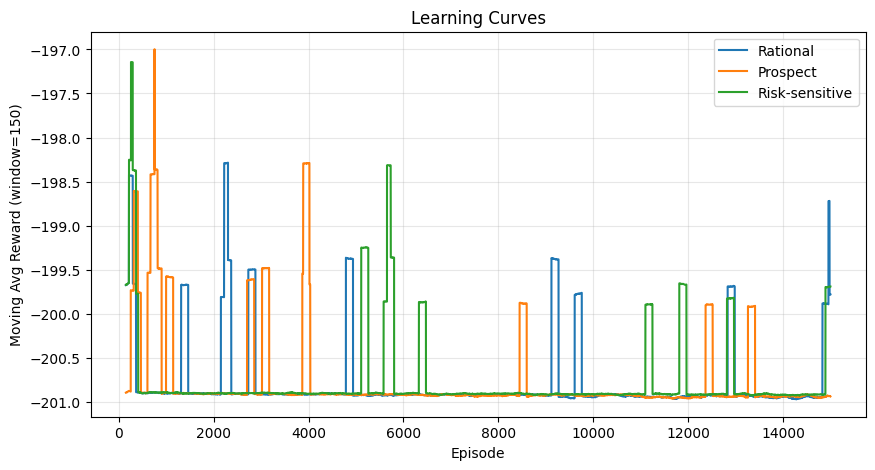

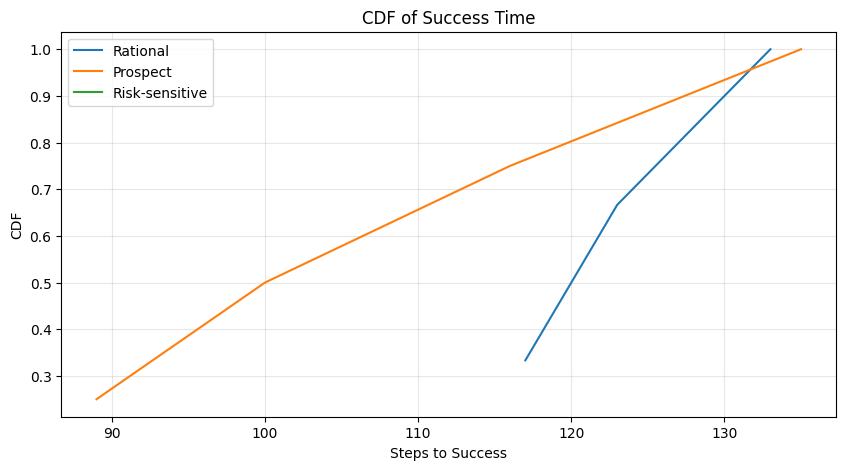

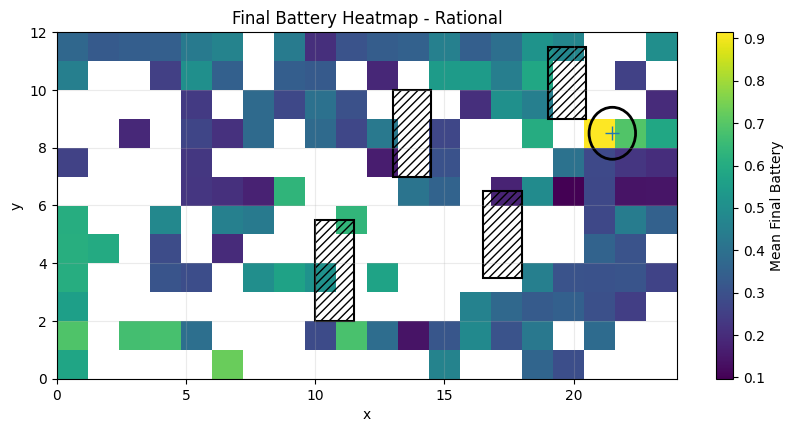

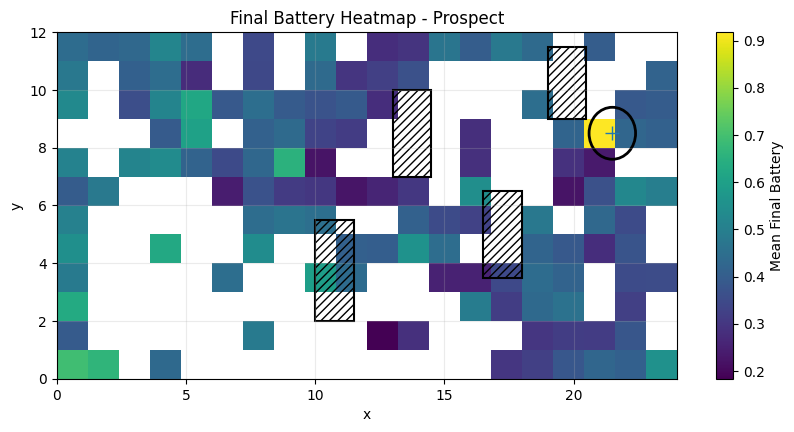

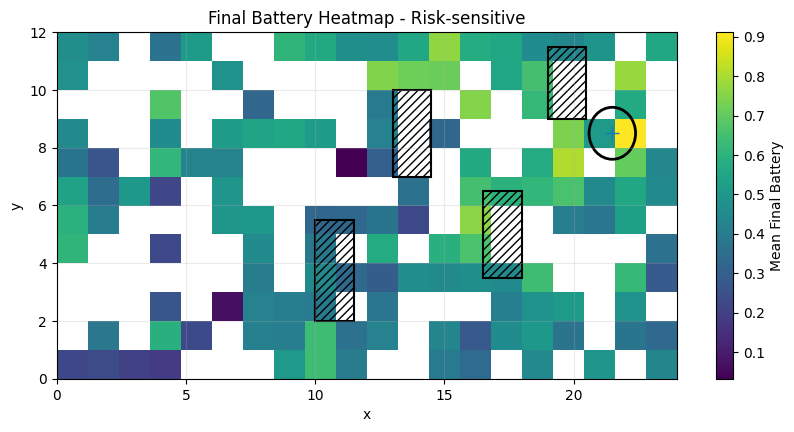

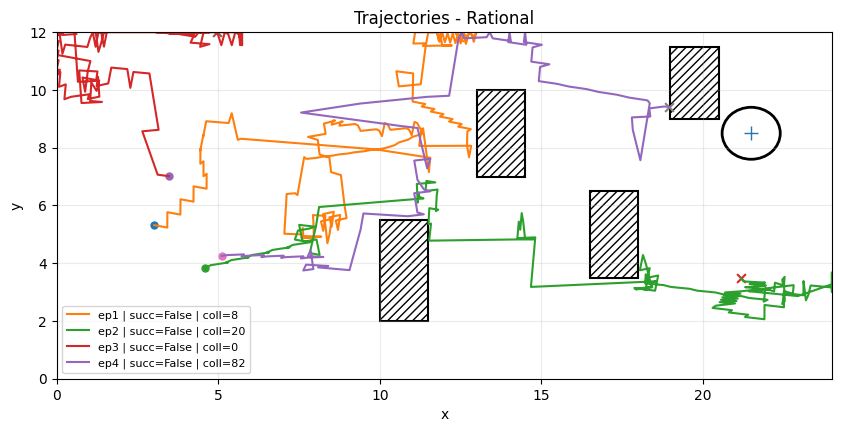

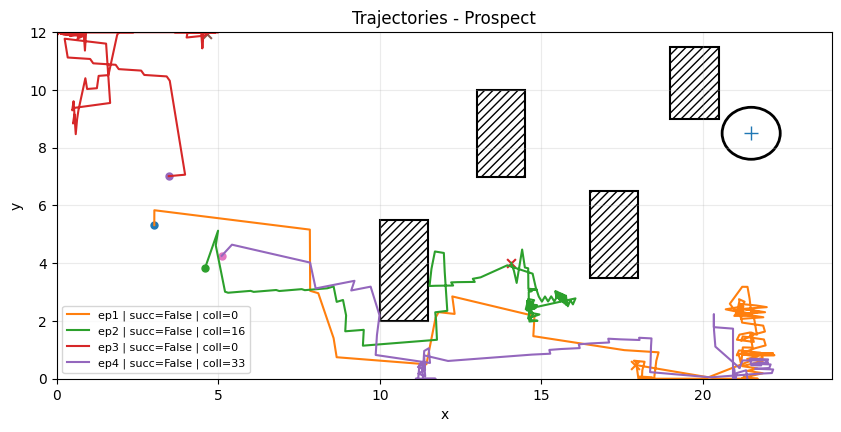

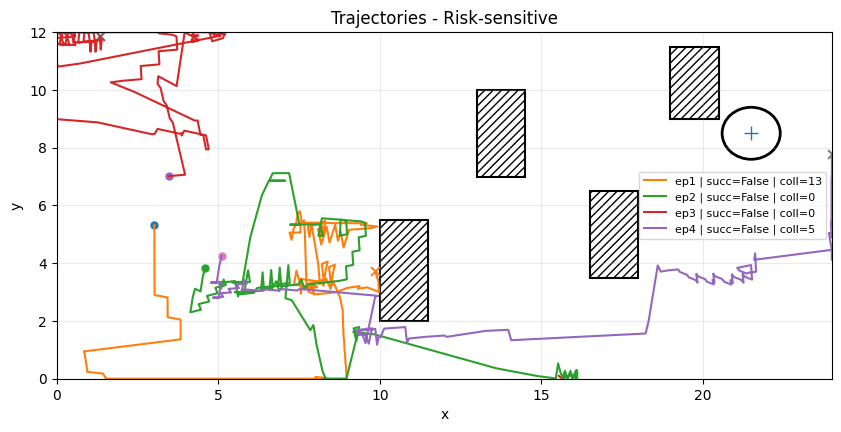

所有图已保存到: /content/task1_3_outputs


In [ ]:
#15. 画图并保存
history_rational = all_runs_data["Rational Q-learning"]["rep_history"]
history_prospect = all_runs_data["Prospect Q-learning"]["rep_history"]
history_risk = all_runs_data["Risk-sensitive Q-learning"]["rep_history"]
results_rational = all_runs_data["Rational Q-learning"]["rep_results"]
results_prospect = all_runs_data["Prospect Q-learning"]["rep_results"]
results_risk = all_runs_data["Risk-sensitive Q-learning"]["rep_results"]

histories = {"Rational": history_rational, "Prospect": history_prospect, "Risk-sensitive": history_risk}
results_dict_rep = {"Rational": results_rational, "Prospect": results_prospect, "Risk-sensitive": results_risk}

plot_learning_curves(histories, window=150, save_path=OUTPUT_DIR / "learning_curves.png")
plot_success_time_cdf(results_dict_rep, save_path=OUTPUT_DIR / "success_time_cdf.png")
plot_final_battery_heatmap(results_rational, ENV_CFG, "Rational", save_path=OUTPUT_DIR / "heatmap_rational.png")
plot_final_battery_heatmap(results_prospect, ENV_CFG, "Prospect", save_path=OUTPUT_DIR / "heatmap_prospect.png")
plot_final_battery_heatmap(results_risk, ENV_CFG, "Risk-sensitive", save_path=OUTPUT_DIR / "heatmap_risk_sensitive.png")
plot_trajectories(results_rational, ENV_CFG, "Rational", save_path=OUTPUT_DIR / "trajectories_rational.png")
plot_trajectories(results_prospect, ENV_CFG, "Prospect", save_path=OUTPUT_DIR / "trajectories_prospect.png")
plot_trajectories(results_risk, ENV_CFG, "Risk-sensitive", save_path=OUTPUT_DIR / "trajectories_risk_sensitive.png")
print("所有图已保存到:", OUTPUT_DIR)